In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Vendedor": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'Gasto': [45,52,38,60,48,55,42,50,58,47,5,53,310,44,49]
})

df

,Vendedor,Gasto
0,1,45
1,2,52
2,3,38
3,4,60
4,5,48
5,6,55
6,7,42
7,8,50
8,9,58
9,10,47


In [21]:
# Número de datos
N = len(df['Gasto'])

# k=1 y k=3
pos_q1 = (1 * (N + 1)) / 4
pos_q3 = (3 * (N + 1)) / 4


q1 = np.percentile(df['Gasto'], 25)
q2 = np.percentile(df['Gasto'], 50)
q3 = np.percentile(df['Gasto'], 75)

RIC = q3 - q1

LI = q1 - (1.5 * RIC)
LS = q3 + (1.5 * RIC)

print(f"Mediana: {q2} ")
print(f"Número total de datos (N): {N}\n")
print(f"Q1: Posición k1: {pos_q1:.2f} | Valor Q1: {q1}")
print(f"Q3: Posición k3: {pos_q3:.2f} | Valor Q3: {q3}")
print(f"RIC: {RIC}")
print(f"Límite Inferior: {LI}")
print(f"Límite Superior: {LS}")

Mediana: 49.0 
Número total de datos (N): 15

Q1: Posición k1: 4.00 | Valor Q1: 44.5
Q3: Posición k3: 12.00 | Valor Q3: 54.0
RIC: 9.5
Límite Inferior: 30.25
Límite Superior: 68.25


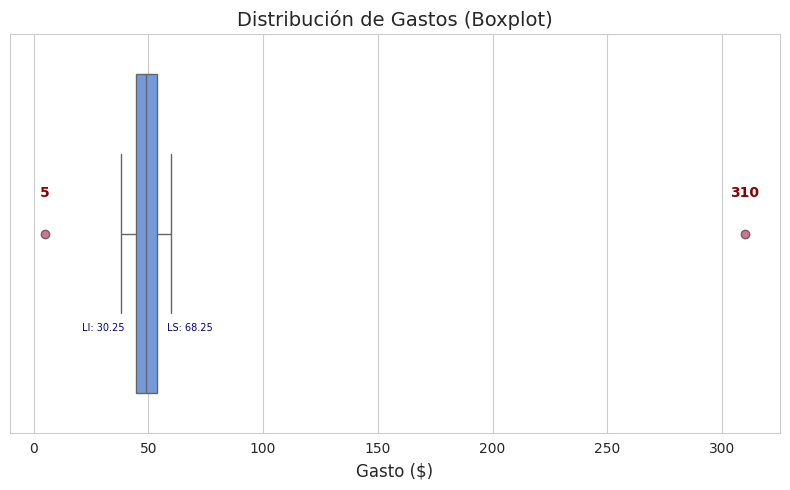

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    x=df['Gasto'],
    color='cornflowerblue',
    fliersize=6,
    flierprops={"markerfacecolor": "palevioletred", "marker": "o"},
    ax=ax
)

#ax.text(x=q2, y=-0.25, s=f'Mediana: {q2}', ha='center', va='top', fontsize=11, color='black')

ax.text(x=LI, y=0.25, s=f'LI: {LI}', ha='center', va='bottom', fontsize=7,  color='darkblue')
ax.text(x=LS, y=0.25, s=f'LS: {LS}', ha='center', va='bottom', fontsize=7,  color='darkblue')

outliers = df[(df['Gasto'] < LI) | (df['Gasto'] > LS)]['Gasto']
for val in outliers:
    ax.text(x=val, y=-0.12, s=f'{val}', ha='center', va='top', fontsize=10, fontweight='bold', color='darkred')

plt.title('Distribución de Gastos (Boxplot)', fontsize=14)
plt.xlabel('Gasto ($)', fontsize=12)
plt.tight_layout()

plt.show()

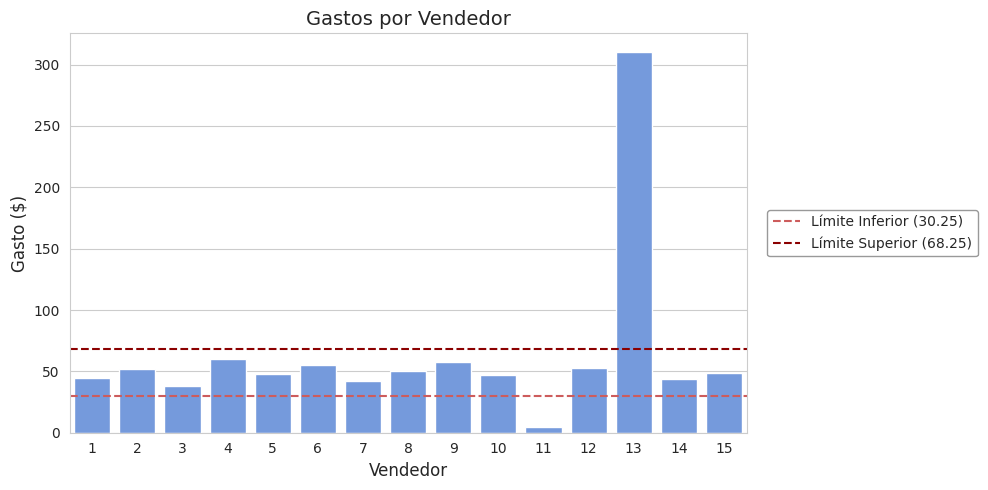

In [23]:
# gráfico de barras

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='Vendedor',
    y='Gasto',
    data=df,
    color='cornflowerblue',
    ax=ax
)

ax.axhline(LI, color='indianred', linestyle='--', linewidth=1.5, label=f'Límite Inferior ({LI})')
ax.axhline(LS, color='darkred', linestyle='--', linewidth=1.5, label=f'Límite Superior ({LS})')

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    fontsize=10
)

plt.title('Gastos por Vendedor', fontsize=14)
plt.xlabel('Vendedor', fontsize=12)
plt.ylabel('Gasto ($)', fontsize=12)
plt.tight_layout()

plt.show()